## 1. Setup & Imports

In [2]:
import os, json, random
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load Natural Image Dataset (CIFAR-10)

In [4]:
from tensorflow.keras.datasets import cifar10
IMG_SIZE = 224

(x_train_cifar,_),(x_test_cifar,_) = cifar10.load_data()
natural_images = np.concatenate([x_train_cifar,x_test_cifar], axis=0)
print("Total Natural Images Available:",natural_images.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1779s 10us/step
Total Natural Images Available: (60000, 32, 32, 3)


## 3. Sample Natural Images & Collect X-ray Paths

In [16]:
NUM_NATURAL = 5228
np.random.shuffle(natural_images)
natural_sample = natural_images[:NUM_NATURAL]
print("Natural images selected:",natural_sample.shape)

xray_dir = "/kaggle/input/datasets/sachinkumar413/covid-pneumonia-normal-chest-xray-images"
xray_paths =[]

for folder in["PNEUMONIA","NORMAL","COVID"]:
    folder_path = os.path.join(xray_dir, folder)
    for fname in os.listdir(folder_path):
        xray_paths.append(os.path.join(folder_path, fname))

print("Total xray images found:", len(xray_paths))

Natural images selected: (5228, 32, 32, 3)
Total xray images found: 5228


## 4. Load & Resize X-ray Images

In [21]:
def load_and_resize_xray(path, size=IMG_SIZE):
    img = cv2.imread(path)  
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img

xray_images = np.array([load_and_resize_xray(p) for p in xray_paths])
print("Xray images shape:", xray_images.shape)

Xray images shape: (5228, 224, 224, 3)


## 6. Train / Validation / Test Split — Gatekeeper

In [22]:
def resize_natural(img, size=IMG_SIZE):
    return cv2.resize(img, (size, size))

natural_resized = np.array([resize_natural(img) for img in natural_sample])
print("Natural images resized shape:", natural_resized.shape)

X_gatekeeper = np.concatenate([xray_images, natural_resized], axis=0)
y_gatekeeper = np.concatenate([
    np.ones(len(xray_images)),      # 1 = xray
    np.zeros(len(natural_resized))  # 0 = not_xray
])

print("Total combined images:", X_gatekeeper.shape)
print("Total labels:", y_gatekeeper.shape)

shuffle_idx = np.random.permutation(len(X_gatekeeper))
X_gatekeeper = X_gatekeeper[shuffle_idx]
y_gatekeeper = y_gatekeeper[shuffle_idx]

Natural images resized shape: (5228, 224, 224, 3)
Total combined images: (10456, 224, 224, 3)
Total labels: (10456,)


## 7. Preprocessing — Gatekeeper Data

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_gatekeeper, y_gatekeeper,
    test_size=0.3,
    stratify=y_gatekeeper,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=SEED
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (7319, 224, 224, 3) (7319,)
Val:   (1568, 224, 224, 3) (1568,)
Test:  (1569, 224, 224, 3) (1569,)


In [25]:
X_train_p = preprocess_input(X_train.astype("float32"))
X_val_p = preprocess_input(X_val.astype("float32"))
X_test_p = preprocess_input(X_test.astype("float32"))

## 8. Build Gatekeeper Model (X-ray vs Not-X-ray)

In [27]:
gatekeeper_base = DenseNet121(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
gatekeeper_base.trainable = False  # Phase 1: freeze base

x = gatekeeper_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
gatekeeper_output = Dense(1, activation="sigmoid")(x)  

gatekeeper_model = Model(inputs=gatekeeper_base.input, outputs=gatekeeper_output)

gatekeeper_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

gatekeeper_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

## 9. Train Gatekeeper Model

In [28]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint("gatekeeper_best.keras", monitor="val_loss", save_best_only=True)
]

history = gatekeeper_model.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=20,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/20
  3/229 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.6128 - loss: 0.6300 

I0000 00:00:1788804926.174650     198 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


229/229 ━━━━━━━━━━━━━━━━━━━━ 69s 186ms/step - accuracy: 0.9951 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 9.8046e-05 - learning_rate: 0.0010
Epoch 2/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 1.0000 - loss: 1.4426e-04 - val_accuracy: 1.0000 - val_loss: 3.4501e-05 - learning_rate: 0.0010
Epoch 3/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 1.0000 - loss: 7.0605e-05 - val_accuracy: 1.0000 - val_loss: 1.3347e-05 - learning_rate: 0.0010
Epoch 4/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 1.0000 - loss: 3.1910e-05 - val_accuracy: 1.0000 - val_loss: 8.4025e-06 - learning_rate: 0.0010
Epoch 5/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 1.0000 - loss: 3.4923e-05 - val_accuracy: 1.0000 - val_loss: 6.6361e-06 - learning_rate: 5.0000e-04
Epoch 6/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 1.0000 - loss: 2.1637e-05 - val_accuracy: 1.0000 - val_loss: 4.7632e-06 - learning_rate: 5.0000e-04
Epoch 7/20
229/229 ━━━━━━━━━━━━━━━

## 10. Evaluate Gatekeeper Model

In [29]:
test_loss, test_acc = gatekeeper_model.evaluate(X_test_p, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Detailed report
y_pred_prob = gatekeeper_model.predict(X_test_p)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=["not_xray", "xray"]))

50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 224ms/step - accuracy: 1.0000 - loss: 1.6152e-06
Test Accuracy: 1.0000
Test Loss: 0.0000
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 250ms/step
              precision    recall  f1-score   support

    not_xray       1.00      1.00      1.00       785
        xray       1.00      1.00      1.00       784

    accuracy                           1.00      1569
   macro avg       1.00      1.00      1.00      1569
weighted avg       1.00      1.00      1.00      1569



## 11. Build Disease Labels from X-ray Folders

In [30]:
disease_labels_list = []

for folder in ["PNEUMONIA", "NORMAL", "COVID"]:
    folder_path = os.path.join(xray_dir, folder)
    count = len(os.listdir(folder_path))
    disease_labels_list.extend([folder] * count)

print("Total disease labels:", len(disease_labels_list))
print("Sample:", disease_labels_list[:5], "...", disease_labels_list[-5:])

Total disease labels: 5228
Sample: ['PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA'] ... ['COVID', 'COVID', 'COVID', 'COVID', 'COVID']


## 12. Config & Data Generators — Disease Classifier

In [32]:
IMG_SIZE_TUPLE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
)

train_gen = train_datagen.flow_from_directory(
    xray_dir,
    target_size=IMG_SIZE_TUPLE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED,
    shuffle=True,
)

val_gen = val_datagen.flow_from_directory(
    xray_dir,
    target_size=IMG_SIZE_TUPLE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED,
    shuffle=False,
)

class_indices = train_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
print("Class indices:", class_indices)

Found 4183 images belonging to 3 classes.
Found 1045 images belonging to 3 classes.
Class indices: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}


## 13. Class Weights — Disease Classifier

In [33]:
labels = train_gen.classes
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels,
)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0717396874199334), 1: np.float64(0.9669440591770689), 2: np.float64(0.968287037037037)}


## 14. Build Disease Classifier Model

In [34]:
disease_base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
disease_base_model.trainable = False  # Phase 1: freeze base

x = disease_base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
disease_output = Dense(NUM_CLASSES, activation="softmax")(x)

disease_model = Model(inputs=disease_base_model.input, outputs=disease_output)
disease_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
disease_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,675 (27.85 MB)

 Trainable params: 263,171 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

## 15. Phase 1 — Train Disease Classifier (Frozen Base)

In [35]:
checkpoint_cb1 = ModelCheckpoint(
    "disease_best_phase1.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)
early_stop_cb = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr_cb = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)

history1 = disease_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=[checkpoint_cb1, early_stop_cb, reduce_lr_cb],
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.7775 - loss: 0.5320
Epoch 1: val_accuracy improved from None to 0.94450, saving model to disease_best_phase1.keras

Epoch 1: finished saving model to disease_best_phase1.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 112s 675ms/step - accuracy: 0.8728 - loss: 0.3277 - val_accuracy: 0.9445 - val_loss: 0.1673 - learning_rate: 0.0010
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9267 - loss: 0.2052
Epoch 2: val_accuracy improved from 0.94450 to 0.95311, saving model to disease_best_phase1.keras

Epoch 2: finished saving model to disease_best_phase1.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 54s 413ms/step - accuracy: 0.9264 - loss: 0.2057 - val_accuracy: 0.9531 - val_loss: 0.1474 - learning_rate: 0.0010
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9297 - loss: 0.1879
Epoch 3: val_accuracy did not improve from 0.95311
131/131 ━━━━━━━━━━━━━━━━━━━━ 52s 396ms/step - accuracy: 0.9283 - loss: 0.1924 - v

## 16. Phase 2 — Fine-tune Disease Classifier

In [36]:
disease_base_model.trainable = True
for layer in disease_base_model.layers[:-30]:
    layer.trainable = False

disease_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

checkpoint_cb2 = ModelCheckpoint(
    "disease_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

history2 = disease_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=[checkpoint_cb2, early_stop_cb, reduce_lr_cb],
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.4580 - loss: 2.7182
Epoch 1: val_accuracy improved from None to 0.95215, saving model to disease_best.keras

Epoch 1: finished saving model to disease_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 123s 695ms/step - accuracy: 0.5388 - loss: 2.0413 - val_accuracy: 0.9522 - val_loss: 0.1652 - learning_rate: 1.0000e-05
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.7649 - loss: 0.8322
Epoch 2: val_accuracy did not improve from 0.95215
131/131 ━━━━━━━━━━━━━━━━━━━━ 54s 408ms/step - accuracy: 0.7889 - loss: 0.7348 - val_accuracy: 0.9493 - val_loss: 0.1784 - learning_rate: 1.0000e-05
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.8460 - loss: 0.4917
Epoch 3: val_accuracy improved from 0.95215 to 0.95502, saving model to disease_best.keras

Epoch 3: finished saving model to disease_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 54s 413ms/step - accuracy: 0.8685 - loss: 0.4241 - val_accuracy: 0.9550 

## 17. Compare Phase 1 vs Phase 2 & Select Best Model

In [37]:
# Load both saved checkpoints and compare on validation set
phase1_model = load_model("disease_best_phase1.keras")
phase2_model = load_model("disease_best.keras")

val_gen.reset()
p1_loss, p1_acc = phase1_model.evaluate(val_gen)

val_gen.reset()
p2_loss, p2_acc = phase2_model.evaluate(val_gen)

print(f"Phase 1 (frozen base):  val_accuracy = {p1_acc:.4f}")
print(f"Phase 2 (fine-tuned):   val_accuracy = {p2_acc:.4f}")

final_disease_model = phase1_model if p1_acc > p2_acc else phase2_model
print("Selected:", "Phase 1" if p1_acc > p2_acc else "Phase 2")

33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 345ms/step - accuracy: 0.9713 - loss: 0.1107
33/33 ━━━━━━━━━━━━━━━━━━━━ 26s 347ms/step - accuracy: 0.9608 - loss: 0.1614
Phase 1 (frozen base):  val_accuracy = 0.9713
Phase 2 (fine-tuned):   val_accuracy = 0.9608
Selected: Phase 1


## 18. Detailed Evaluation — Classification Report & Confusion Matrix

33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 458ms/step
              precision    recall  f1-score   support

       COVID       0.99      0.99      0.99       325
      NORMAL       0.96      0.97      0.96       360
   PNEUMONIA       0.97      0.96      0.96       360

    accuracy                           0.97      1045
   macro avg       0.97      0.97      0.97      1045
weighted avg       0.97      0.97      0.97      1045



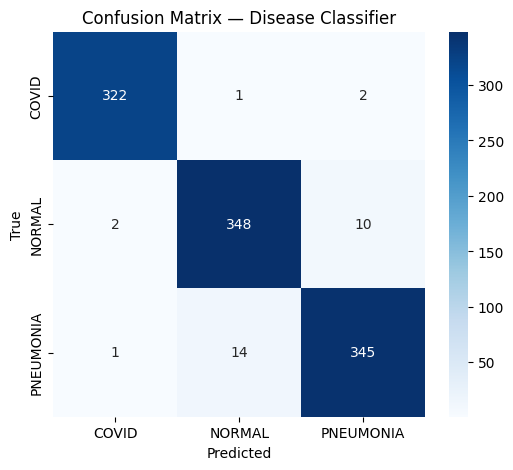

In [38]:
val_gen.reset()
preds = final_disease_model.predict(val_gen)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

class_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix — Disease Classifier")
plt.show()

## 19. Training Curves (Phase 1 + Phase 2)

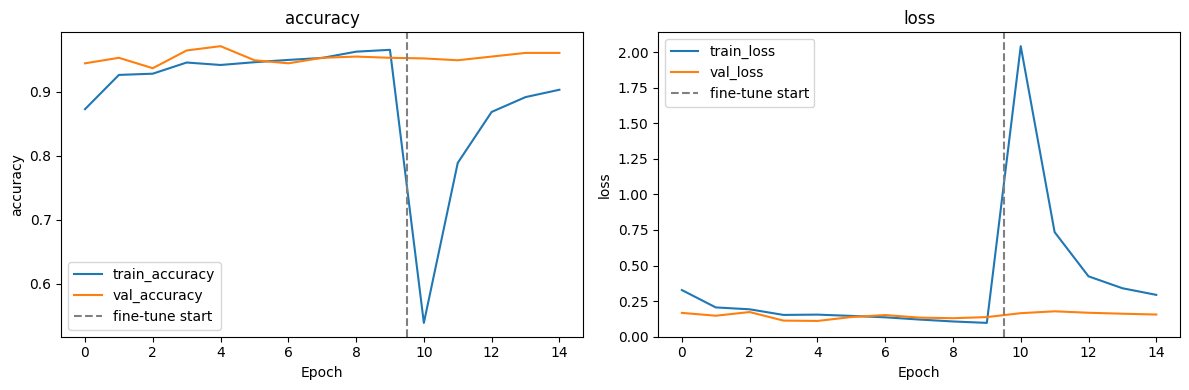

In [41]:
def plot_history(h1, h2, metric):
    vals = h1.history[metric] + h2.history[metric]
    val_vals = h1.history[f"val_{metric}"] + h2.history[f"val_{metric}"]
    plt.plot(vals, label=f"train_{metric}")
    plt.plot(val_vals, label=f"val_{metric}")
    plt.axvline(x=len(h1.history[metric]) - 0.5, color="gray", linestyle="--", label="fine-tune start")
    plt.xlabel("Epoch"); plt.ylabel(metric); plt.legend(); plt.title(metric)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plot_history(history1, history2, "accuracy")
plt.subplot(1, 2, 2)
plot_history(history1, history2, "loss")
plt.tight_layout()
plt.show()

## 20. Combined Prediction Pipeline (Gatekeeper + Disease Classifier)

In [45]:
class_labels = [idx_to_class[i] for i in range(NUM_CLASSES)] 

def predict_pipeline(img_path, gatekeeper_threshold=0.5):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_array = np.expand_dims(img.astype("float32"), axis=0)
    img_preprocessed = preprocess_input(img_array)

    # Stage 1: Gatekeeper
    xray_prob = gatekeeper_model.predict(img_preprocessed, verbose=0)[0][0]

    if xray_prob < gatekeeper_threshold:
        return {
            "is_xray": False,
            "message": "This is not an X-ray image",
            "xray_confidence": float(xray_prob)
        }

    # Stage 2: Disease classification
    disease_pred = final_disease_model.predict(img_preprocessed, verbose=0)[0]
    predicted_class = class_labels[np.argmax(disease_pred)]
    confidence = float(np.max(disease_pred))

    return {
        "is_xray": True,
        "predicted_class": predicted_class,
        "confidence": confidence,
        "xray_confidence": float(xray_prob)
    }
test_natural_img = natural_sample[0]  
cv2.imwrite("test_natural.jpg", cv2.cvtColor(test_natural_img, cv2.COLOR_RGB2BGR))


result = predict_pipeline("test_natural.jpg")
print("Non-xray test result:", result)

print(predict_pipeline(xray_paths[0]))

Non-xray test result: {'is_xray': False, 'message': 'This is not an X-ray image', 'xray_confidence': 1.2000374305376482e-10}
{'is_xray': True, 'predicted_class': 'PNEUMONIA', 'confidence': 0.9999741315841675, 'xray_confidence': 0.9999998807907104}


## 21. Grad-CAM Visualization

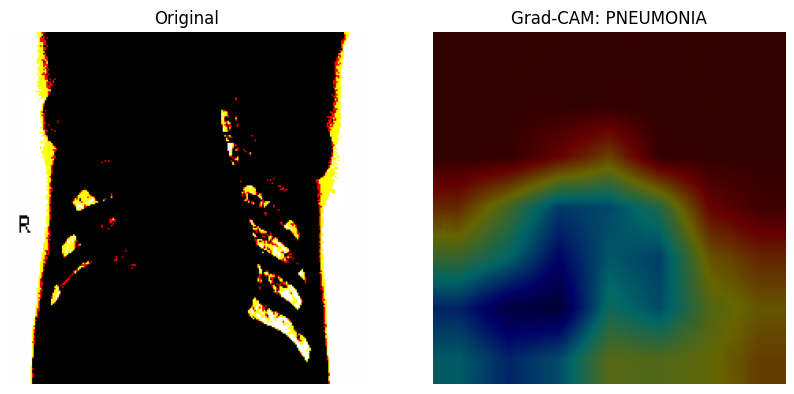

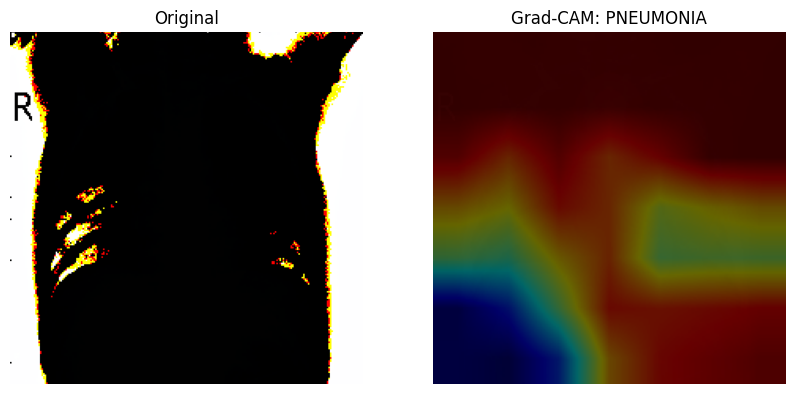

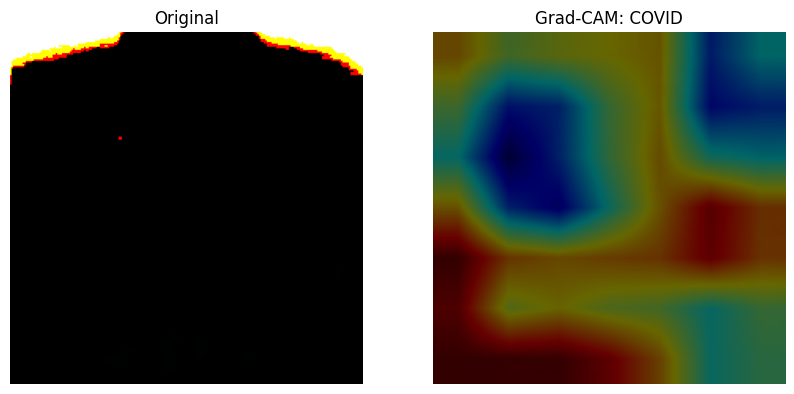

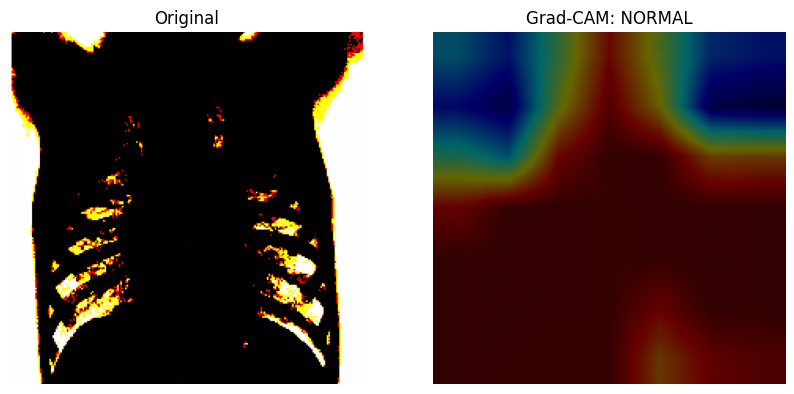

In [42]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name="conv5_block16_2_conv"):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(class_idx)


def display_gradcam(img_path, model, img_size=(224, 224), alpha=0.4):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_input = preprocess_input(np.expand_dims(img_array, axis=0))

    heatmap, class_idx = get_gradcam_heatmap(model, img_input)
    heatmap = cv2.resize(heatmap, img_size)
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = heatmap_color * alpha + img_array
    superimposed = np.uint8(np.clip(superimposed, 0, 255))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_array.astype("uint8")); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(superimposed); axes[1].set_title(f"Grad-CAM: {idx_to_class[class_idx]}"); axes[1].axis("off")
    plt.show()

# Test on a few sample images
import random as _random
sample_paths = _random.sample(list(train_gen.filepaths), 4)
for p in sample_paths:
    display_gradcam(p, final_disease_model)

## 22. Save Model Config for API

In [43]:
api_config = {
    "disease_class_indices": class_indices,
    "disease_idx_to_class": idx_to_class,
    "img_size": [IMG_SIZE, IMG_SIZE],
    "preprocessing": "densenet_preprocess_input",
    "model_architecture": "DenseNet121",
    "input_shape": [224, 224, 3],
    "gatekeeper_threshold": 0.5,
}

with open("model_config.json", "w") as f:
    json.dump(api_config, f, indent=2)

print(json.dumps(api_config, indent=2))

{
  "disease_class_indices": {
    "COVID": 0,
    "NORMAL": 1,
    "PNEUMONIA": 2
  },
  "disease_idx_to_class": {
    "0": "COVID",
    "1": "NORMAL",
    "2": "PNEUMONIA"
  },
  "img_size": [
    224,
    224
  ],
  "preprocessing": "densenet_preprocess_input",
  "model_architecture": "DenseNet121",
  "input_shape": [
    224,
    224,
    3
  ],
  "gatekeeper_threshold": 0.5
}
